In [51]:
import datetime
import os
from glob import glob
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter

### Load data

In [23]:
data_path = 'ME4OH_EN411_OFAM3/data/en4.1.1/1993-2014/'
files = [f for f in glob(os.path.join(data_path, "*.nc"))]

In [24]:
def load_and_filter_ohc(filepath):
    """Load data file, extract variables, filter for layer 1 OHC"""
    file_data = nc.Dataset(filepath,'r')

    # Extract variables
    lat = file_data["ts_lat"][:].data  # Latitude
    long = file_data["ts_lon"][:].data  # Longitude
    time = file_data["en4_ymd"][:].data  # Year , month , day
    mask = file_data["dohc_mask_by_en4_maxdepth"][:].data # Valid profile mask
    dohc1 = file_data["dohc"][:, 0].data  # Layer 1 OHC anomaly target (NOTE: index 0 in python, index 1 in R)
    ssh = file_data["eta_t"][:].data  # Sea surface height

    # Filter to valid OHC
    # Only valid Layer-1 profiles included according to mask and remove NaNs
    idx = [i for i in range(len(mask)) if mask[i, 0] == 1]
    filtered_dohc1 = np.array([dohc1[i] for i in idx])
    filtered_lat = np.array([lat[i] for i in idx])
    filtered_long = np.array([long[i] for i in idx])
    filtered_date = np.array([datetime.date(int(time[i, 0]), int(time[i, 1]), int(time[i, 2])) for i in idx])
    filtered_ssh = np.array([ssh[i] for i in idx])

    # Make df
    ohc_df = pd.DataFrame({
        "Date": filtered_date,
        "Latitude": filtered_lat,
        "Longitude": filtered_long,
        "OHC": filtered_dohc1,
        "SSH": filtered_ssh
    })
    ohc_df = ohc_df.dropna()
    
    return ohc_df
    

In [25]:
# Temporarily filter to only 10 files
# files = files[0:10]

In [26]:
ohc_df = load_and_filter_ohc(files[0])
for path in files[1:]:
    file_df = load_and_filter_ohc(path)
    ohc_df = pd.concat([ohc_df, file_df])

ohc_df

,Date,Latitude,Longitude,OHC,SSH
0,1993-09-12,-65.050003,236.649994,0.343876,-1.691031
1,1993-09-10,-64.050003,221.550003,0.344592,-1.746879
2,1993-09-15,-63.549999,244.350006,0.345307,-1.345561
3,1993-09-11,-63.349998,278.549988,0.345918,-1.107517
4,1993-09-12,-62.849998,219.149994,0.344311,-1.786248
...,...,...,...,...,...
7445,1995-06-28,73.650002,19.150000,0.347956,-0.737022
7446,1995-06-29,73.750000,13.250000,0.348566,-0.766320
7447,1995-06-05,73.750000,13.350000,0.348498,-0.795618
7448,1995-06-29,73.750000,13.350000,0.348606,-0.762963


# EDA

- Amount of data points across time
- Amount of data across space
- Plot OHC vs lat long for a single month?

In [ ]:


ohc_df['Date'] = pd.to_datetime(ohc_df['Date'])

sept_93 = ohc_df.loc[(ohc_df['Date'].dt.month == 9) & (ohc_df['Date'].dt.year == 1993)]
sept_93

,Date,Latitude,Longitude,OHC,SSH
0,1993-09-12,-65.050003,236.649994,0.343876,-1.691031
1,1993-09-10,-64.050003,221.550003,0.344592,-1.746879
2,1993-09-15,-63.549999,244.350006,0.345307,-1.345561
3,1993-09-11,-63.349998,278.549988,0.345918,-1.107517
4,1993-09-12,-62.849998,219.149994,0.344311,-1.786248
...,...,...,...,...,...
7534,1993-09-30,74.150002,25.049999,0.349755,-0.654927
7535,1993-09-30,74.150002,28.049999,0.349318,-0.614948
7536,1993-09-07,74.250000,23.650000,0.348376,-0.676290
7537,1993-09-07,74.250000,25.250000,0.349148,-0.672628


In [73]:
df = ohc_df.copy(deep=True)

In [78]:
df.sort_values('Date').reset_index(drop=True)

,Date,Latitude,Longitude,OHC,SSH
0,1993-01-01,5.050000,327.850006,0.366546,0.058901
1,1993-01-01,29.150000,340.250000,0.365908,-0.245369
2,1993-01-01,7.450000,72.650002,0.369750,0.487075
3,1993-01-01,0.150000,319.350006,0.367728,0.051881
4,1993-01-01,0.150000,156.050003,0.371011,0.643025
...,...,...,...,...,...
6170103,2014-12-31,-55.049999,295.149994,0.352809,-0.217292
6170104,2014-12-31,-35.250000,200.850006,0.362071,0.086062
6170105,2014-12-31,-54.849998,62.049999,0.345977,-1.217078
6170106,2014-12-31,-55.250000,81.650002,0.345617,-1.592761


In [56]:
monthly_means = df.groupby(df['Date'].dt.strftime('%m/%Y'))['OHC'].mean().sort_values()

In [71]:
monthly_means.reset_index()

,Date,OHC
0,03/2009,0.360067
1,02/2009,0.360827
2,04/2009,0.360930
3,04/2010,0.361323
4,05/2009,0.361366
...,...,...
259,10/2001,0.366289
260,11/1993,0.366311
261,09/1994,0.366334
262,10/1994,0.366349


In [72]:
sns.lineplot(monthly_means, x='Date', y='OHC')

TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.Series'>.

In [61]:
df.set_index('Date')

,Latitude,Longitude,OHC,SSH
Date,,,,
1993-09-12,-65.050003,236.649994,0.343876,-1.691031
1993-09-10,-64.050003,221.550003,0.344592,-1.746879
1993-09-15,-63.549999,244.350006,0.345307,-1.345561
1993-09-11,-63.349998,278.549988,0.345918,-1.107517
1993-09-12,-62.849998,219.149994,0.344311,-1.786248
...,...,...,...,...
1995-06-28,73.650002,19.150000,0.347956,-0.737022
1995-06-29,73.750000,13.250000,0.348566,-0.766320
1995-06-05,73.750000,13.350000,0.348498,-0.795618


AttributeError: 'Index' object has no attribute 'month'

In [66]:
df_by_month = df.groupby(pd.PeriodIndex(df['Date'], freq="M"))['OHC'].mean().reset_index()

In [67]:
df_by_month

,Date,OHC
0,1993-01,0.365208
1,1993-02,0.365063
2,1993-03,0.365388
3,1993-04,0.364328
4,1993-05,0.365214
...,...,...
259,2014-08,0.363326
260,2014-09,0.363922
261,2014-10,0.364277
262,2014-11,0.364518


TypeError: float() argument must be a string or a real number, not 'Period'

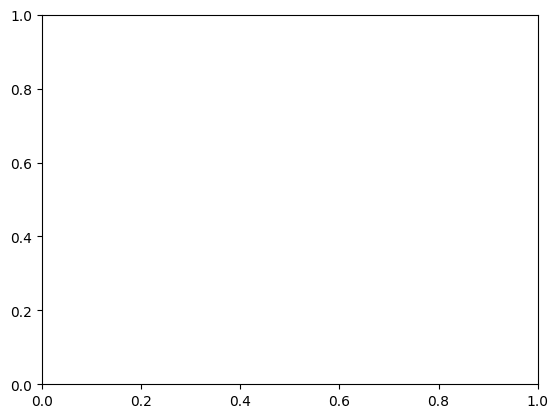

In [70]:
plt.plot(df_by_month['Date'], df_by_month["OHC"])
ax = plt.gca()
ax.xaxis.set_major_locator(MonthLocator(interval=6))
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

TypeError: Invalid object type at position 0

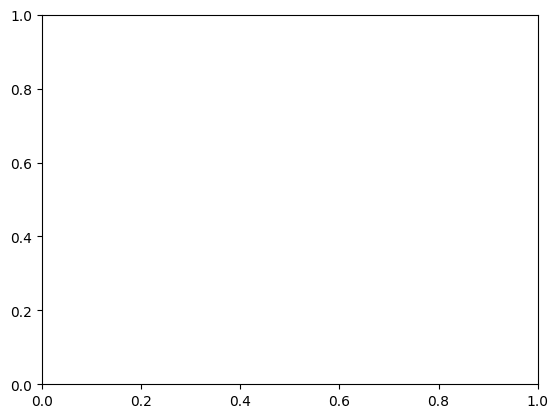

In [68]:
sns.lineplot(df_by_month, x='Date', y='OHC')